### Imports

In [45]:
import os
import re
import pickle
import warnings

import numpy as np
import pandas as pd

from scipy.sparse import hstack

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

### Load Artifacts

In [ ]:
def load_artifacts():
    with open("../models/intent_classification/best_intent_classifier.pkl", "rb") as f:
        best_model = pickle.load(f)

    with open("../models/intent_classification/word_vectorizer.pkl", "rb") as f:
        word_vectorizer = pickle.load(f)

    with open("../models/intent_classification/char_vectorizer.pkl", "rb") as f:
        char_vectorizer = pickle.load(f)

    with open("../models/intent_classification/label_encoder.pkl", "rb") as f:
        label_encoder = pickle.load(f)

    print("Artifacts Loaded Successfully")

    return (best_model, word_vectorizer, char_vectorizer, label_encoder)

(best_model, word_vectorizer, char_vectorizer, label_encoder) = load_artifacts()

Artifacts Loaded Successfully


#### Configuration

In [47]:
CONFIDENCE_THRESHOLD = 60

### Text Preprocessing

In [ ]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub( r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

#### Confidence Band

In [ ]:
def get_confidence_band(confidence):
    if confidence >= 80:
        return "High"

    elif confidence >= 60:
        return "Medium"

    elif confidence >= 40:
        return "Low"

    else:
        return "Very Low"

#### Feature Engineering

In [ ]:
def create_features(text_series):
    word_features = (word_vectorizer.transform(text_series))
    char_features = (char_vectorizer.transform(text_series))

    combined_features = hstack([word_features, char_features])

    return combined_features

### Single Question Prediction

In [ ]:
def predict_question(question):
    clean_question = preprocess_text(question)
    features = create_features(pd.Series([clean_question]))
    prediction = (best_model.predict(features))[0]
    confidence = (best_model.predict_proba(features).max() * 100)
    predicted_label = (label_encoder.inverse_transform([prediction])[0])

    return {
        "Question": question,
        "clean_question": clean_question,
        "Predicted_Intent": predicted_label,
        "Confidence": round(confidence, 2),
        "Confidence_Band": get_confidence_band(confidence),
        "Review_Required": ("Yes" if confidence < CONFIDENCE_THRESHOLD else "No")
    }

#### DataFrame Prediction

In [ ]:
def predict_dataframe(df):
    df = df.copy()

    if "Question" not in df.columns:
        raise ValueError("Question column not found.")

    df["clean_question"] = (
        df["Question"]
        .astype(str)
        .apply(preprocess_text)
        )

    features = create_features(df["clean_question"])
    predictions = (best_model.predict(features))
    confidences = (best_model.predict_proba(features).max(axis=1) * 100)
    predicted_labels = (label_encoder.inverse_transform(predictions))

    df["Predicted_Intent"] = (predicted_labels)
    df["Confidence"] = (np.round(confidences, 2))
    df["Confidence_Band"] = (df["Confidence"].apply(get_confidence_band))
    df["Review_Required"] = np.where(df["Confidence"] < CONFIDENCE_THRESHOLD, "Yes", "No")

    return df[[
            "Question",
            "clean_question",
            "Predicted_Intent",
            "Confidence",
            "Confidence_Band",
            "Review_Required"]]

#### File Prediction

Supports CSV and Excel.

In [ ]:
def predict_file(file_path):
    extension = (os.path.splitext(file_path)[1].lower())

    if extension == ".csv":
        try:
            df = pd.read_csv(file_path, encoding="utf-8")
        except:
            df = pd.read_csv(file_path, encoding="latin1")
    elif extension in [".xlsx", ".xls"]:
        df = pd.read_excel( file_path)
    else:
        raise ValueError("Only CSV and Excel files are supported.")

    return predict_dataframe(df)

#### Folder Prediction

In [ ]:
def predict_folder(folder_path):
    output_folder = os.path.join(folder_path, "predictions")

    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(folder_path):
        if file.endswith((".csv", ".xlsx", ".xls")):
            print(f"Processing: {file}")

            file_path = os.path.join(folder_path, file)
            output_df = predict_file(file_path)
            output_name = (os.path.splitext(file)[0] + "_predictions.csv")

            output_df.to_csv(os.path.join(output_folder, output_name), index=False)

    print("Folder prediction completed.")

### Universal Prediction Function

In [ ]:
def predict(input_data):
    if isinstance(input_data, pd.DataFrame):
        return predict_dataframe(input_data)

    if isinstance(input_data, str):
        if os.path.isfile(input_data):
            return predict_file(input_data)
        elif os.path.isdir(input_data):
            return predict_folder(input_data)
        else:
            return predict_question(input_data)

### Test

In [ ]:
predict("How can I reset my SBI password?")

{'Question': 'How can I reset my SBI password?',
 'clean_question': 'how can i reset my sbi password',
 'Predicted_Intent': 'Cards & Payments',
 'Confidence': 45.73,
 'Confidence_Band': 'Low',
 'Review_Required': 'Yes'}

In [ ]:
verification_df = predict("../data/verification_data/banking_faq_custom_categories_100.csv")

verification_df.sample(5)

,Question,clean_question,Predicted_Intent,Confidence,Confidence_Band,Review_Required
62,Can I track complaint status?,can i track complaint status,Investments & Insurance,38.57,Very Low,Yes
11,How long does IMPS take?,how long does imps take,Digital & Security,35.41,Very Low,Yes
55,What is inflation?,what is inflation,Customer Support,65.28,Medium,No
25,How do I apply for a personal loan?,how do i apply for a personal loan,Loans,62.04,Medium,No
98,Can I schedule fund transfers? (99),can i schedule fund transfers,Investments & Insurance,70.71,Medium,No


In [58]:
# predict("../data/incoming_files").sample(5)

### Save Prediction File

In [ ]:
verification_df.to_csv("../data/output/predicted_output.csv", index=False)

print("Prediction file saved successfully!")

Prediction file saved successfully!


### Report

In [ ]:
print("=" * 60)
print("MODEL PREDICTION REPORT")
print("=" * 60)

total_records = len(verification_df)
avg_confidence = (verification_df["Confidence"].mean())
min_confidence = (verification_df["Confidence"].min())
max_confidence = (verification_df["Confidence"].max())
review_required_count = (verification_df["Review_Required"] == "Yes").sum()
auto_approved_count = (verification_df["Review_Required"] == "No").sum()

print(f"Total Records           : {total_records}")
print(f"Average Confidence      : {avg_confidence:.2f}%")
print(f"Minimum Confidence      : {min_confidence:.2f}%")
print(f"Maximum Confidence      : {max_confidence:.2f}%")
print(f"Review Required         : {review_required_count}")
print(f"Auto Approved           : {auto_approved_count}")

print("=" * 60)

MODEL PREDICTION REPORT
Total Records           : 100
Average Confidence      : 58.76%
Minimum Confidence      : 26.52%
Maximum Confidence      : 92.17%
Review Required         : 48
Auto Approved           : 52


#### Confidence Band Summary

In [ ]:
verification_df["Confidence_Band"].value_counts()

Confidence_Band
Medium      37
Low         26
Very Low    22
High        15
Name: count, dtype: int64

#### Intent Distribution

In [ ]:
intent_distribution = (
    verification_df["Predicted_Intent"]
    .value_counts()
    .reset_index()
)

intent_distribution.columns = ["Intent", "Count"]

intent_distribution["Percentage"] = (intent_distribution["Count"] / len(verification_df) * 100).round(2)

intent_distribution

,Intent,Count,Percentage
0,Retail Banking,24,24.0
1,Investments & Insurance,22,22.0
2,Customer Support,17,17.0
3,Loans,17,17.0
4,Cards & Payments,11,11.0
5,Digital & Security,9,9.0


#### Confidence Statistics

In [ ]:
confidence_summary = pd.DataFrame({
    "Metric": ["Mean", "Median", "Min", "Max", "Std Dev"],
    "Value": [
        verification_df["Confidence"].mean(),
        verification_df["Confidence"].median(),
        verification_df["Confidence"].min(),
        verification_df["Confidence"].max(),
        verification_df["Confidence"].std()
    ]
})

confidence_summary

,Metric,Value
0,Mean,58.761700
1,Median,60.660000
2,Min,26.520000
3,Max,92.170000
4,Std Dev,18.390594


#### Review Required Analysis

In [ ]:
review_summary = (
    verification_df["Review_Required"]
    .value_counts()
    .reset_index()
)

review_summary.columns = ["Review Required", "Count"]

review_summary

,Review Required,Count
0,No,52
1,Yes,48


#### Visualization

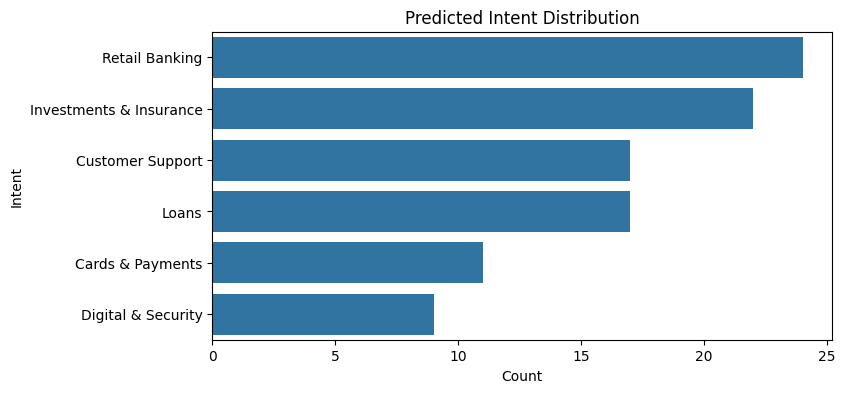

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.countplot(
    y="Predicted_Intent",
    data=verification_df,
    order=verification_df[ "Predicted_Intent"].value_counts().index
)

plt.title("Predicted Intent Distribution")
plt.xlabel("Count")
plt.ylabel("Intent")

plt.show()

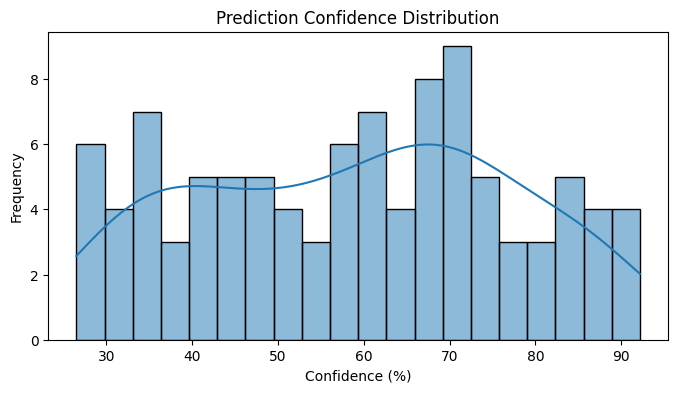

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(verification_df["Confidence"], bins=20, kde=True)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence (%)")
plt.ylabel("Frequency")

plt.show()

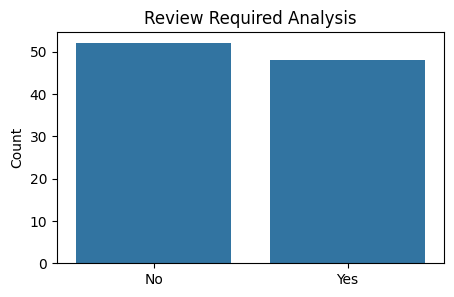

In [ ]:
plt.figure(figsize=(5,3))

sns.countplot(x="Review_Required", data=verification_df)

plt.title("Review Required Analysis")
plt.xlabel("")
plt.ylabel("Count")

plt.show()

### Calculate Accuracy (Only if actual labels exist.)

In [ ]:
verification_df = pd.read_csv(
    "../data/verification_data/banking_faq_custom_categories_100.csv",
    encoding="latin1"
)

prediction_df = predict_dataframe(
    verification_df
)

verification_df[
    "Category"
] = (
    verification_df[
        "Category"
    ]
    .str.lower()
    .str.strip()
)

prediction_df[
    "Predicted_Intent"
] = (
    prediction_df[
        "Predicted_Intent"
    ]
    .str.lower()
    .str.strip()
)

In [ ]:
accuracy = accuracy_score(
    verification_df["Category"],
    prediction_df["Predicted_Intent"]
)

print(
    f"Verification Accuracy: {accuracy:.4f}"
)

### Classification Report

In [ ]:
print(
    classification_report(
        verification_df["Category"],
        prediction_df["Predicted_Intent"]
    )
)

### Prediction Status

In [20]:
true_labels = (
    verification_df["Category"]
    .str.lower()
    .str.strip()
)

pred_labels = (
    prediction_df["Predicted_Intent"]
    .str.lower()
    .str.strip()
)

In [ ]:
# Prediction Status
verification_df["Prediction_Status"] = (
    true_labels == pred_labels
)

# Statistics
correct_predictions = (
    verification_df["Prediction_Status"].sum()
)

total_predictions = len(
    verification_df
)

incorrect_predictions = (
    total_predictions
    - correct_predictions
)

accuracy_percent = (
    accuracy * 100
)

print(
    f"Total Predictions      : {total_predictions}"
)

print(
    f"Correct Predictions    : {correct_predictions}"
)

print(
    f"Incorrect Predictions  : {incorrect_predictions}"
)

print(
    f"Verification Accuracy  : {accuracy_percent:.2f}%"
)

print("=" * 60)

### Correct Predictions Count

In [ ]:
correct_predictions = (
    verification_df["Prediction_Status"].sum()
)

total_predictions = len(verification_df)

print("Correct Predictions:", correct_predictions)
print("Total Predictions:", total_predictions)

### Accuracy Percentage

In [ ]:
accuracy_percent = accuracy * 100

print(
    f"Model Accuracy on Verification File: "
    f"{accuracy_percent:.2f}%"
)

# Key Insights & Observations

## Verification Dataset Evaluation

A separate verification dataset was used for external validation.

### Observation
- The trained pipeline successfully predicted intents for unseen banking queries.
- Real-world testing improved confidence in model robustness.

### Evaluation Metrics
The notebook evaluated:
- training accuracy
- testing accuracy
- cross-validation accuracy
- overfitting gap

This provided a comprehensive performance assessment.